# Data Analysis

# 0. Package Import :

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Business and Data Understanding:

### this step aims to identify:

###### Read Data

In [2]:
file_path = r"C:\pfe\fraud_detection_dataset.csv" 
df = pd.read_csv(file_path)

###### First five rows 

In [3]:

print(df.head())

             timestamp                               user_id  amount  \
0  2023-12-15 02:48:24  3cbf0b8a-c799-4c0e-9782-89272ab8fa2b  998.99   
1  2023-10-30 11:08:37  3675ed98-6863-4bae-b089-6f0db2df006b  241.39   
2  2023-11-21 05:19:35  4be1043f-20ee-4ac5-a689-b25c6a1de50c  836.42   
3  2023-11-07 00:03:25  cad0b3c9-099f-479b-8043-6d5ecb4e1467  612.74   
4  2023-04-02 14:12:23  b6ebea7d-ba62-41d7-b042-3978a23fef8b  135.55   

          location device_type  is_fraud  age     income      debt  \
0        Grantfurt      Mobile         0   56   42524.98   8394.05   
1  Kimberlychester      Tablet         0   52   69884.04  28434.06   
2   Gutierrezville     Desktop         0   58  126953.62  39121.78   
3         Markside     Desktop         0   19  128650.70  39652.48   
4     Anthonyshire      Tablet         0   59  102020.39   7439.81   

   credit_score  
0           655  
1           395  
2           496  
3           612  
4           302  


###### info data 

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 10 columns):
 #   Column        Dtype  
---  ------        -----  
 0   timestamp     str    
 1   user_id       str    
 2   amount        float64
 3   location      str    
 4   device_type   str    
 5   is_fraud      int64  
 6   age           int64  
 7   income        float64
 8   debt          float64
 9   credit_score  int64  
dtypes: float64(3), int64(3), str(4)
memory usage: 152.6 MB


In [5]:
# Convert timestamp to datetime (if not already)
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Extract time features
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.day_name()

# Create age groups (adjust bins if needed)
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 18, 30, 40, 50, 60, 100],
    labels=['<18', '18-30', '31-40', '41-50', '51-60', '60+'],
    right=False
)

# Null values
null_counts = df.isnull().sum()
null_percent = (null_counts / len(df)) * 100

print("Valeurs nulles par colonne :")
print(null_counts)

print("\nPourcentage des valeurs nulles :")
print(null_percent)

# Duplicates
print("\nNombre de doublons :", df.duplicated().sum())


Valeurs nulles par colonne :
timestamp       0
user_id         0
amount          0
location        0
device_type     0
is_fraud        0
age             0
income          0
debt            0
credit_score    0
hour            0
day_of_week     0
age_group       0
dtype: int64

Pourcentage des valeurs nulles :
timestamp       0.0
user_id         0.0
amount          0.0
location        0.0
device_type     0.0
is_fraud        0.0
age             0.0
income          0.0
debt            0.0
credit_score    0.0
hour            0.0
day_of_week     0.0
age_group       0.0
dtype: float64

Nombre de doublons : 0


###### number of rows and columns

In [6]:
df.shape

(2000000, 13)

###### info class fraud vs no fraud

In [7]:
df.is_fraud.unique()

array([0, 1], dtype=int64)

###### is_fraud plot 

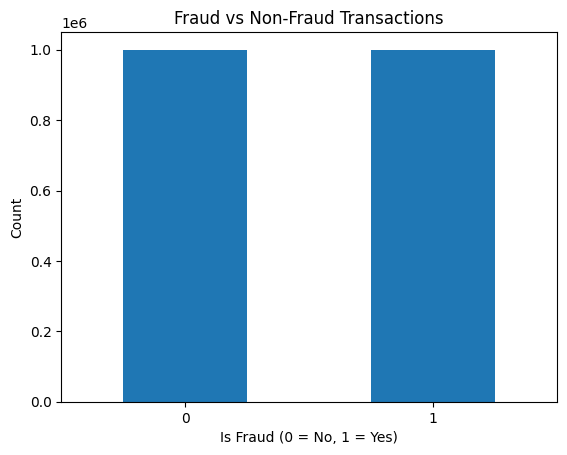

In [8]:
plt.figure()
df["is_fraud"].value_counts().plot(kind="bar")
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Is Fraud (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

###### Duplicate VS Non Duplicate 

### 2.4 Data Check 

##### 2.4.1 Check Nulls 

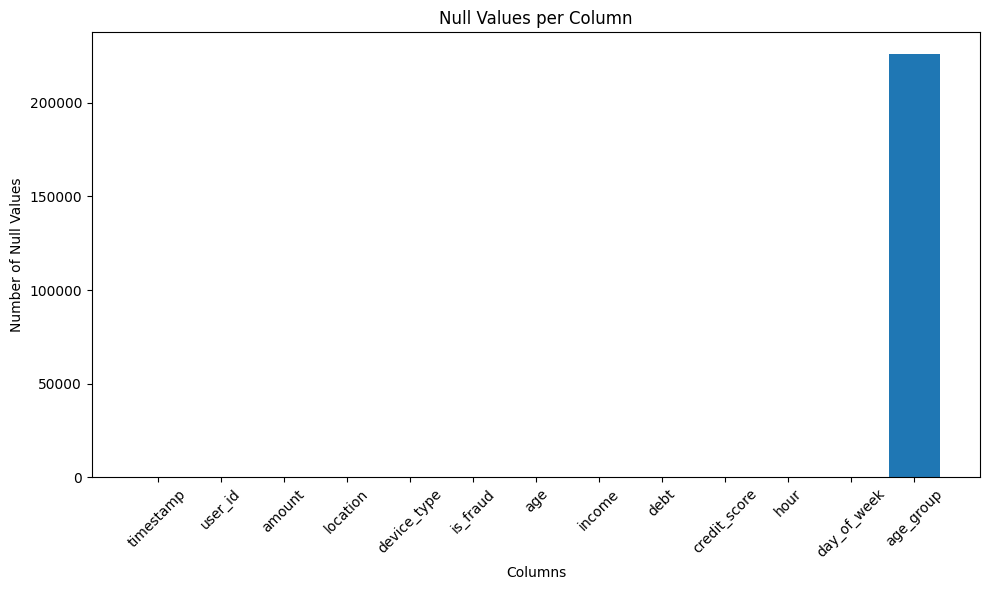

In [9]:
bins = [18, 25, 35, 45, 55, 65]
labels = ["18-24", "25-34", "35-44", "45-54", "55-64"]

# Create age_group
df["age_group"] = pd.cut(df["age"], bins=bins)

# Count nulls created by binning
# Count null values in each column (including age_group)
null_counts = df.isnull().sum()

# Plot
plt.figure(figsize=(10,6))
plt.bar(null_counts.index, null_counts.values)

plt.xlabel("Columns")
plt.ylabel("Number of Null Values")
plt.title("Null Values per Column")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 2.4.2 Duplicates 

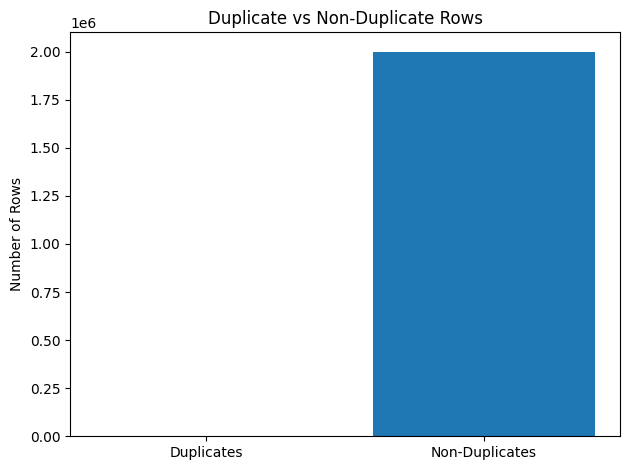

In [10]:
# Count duplicates
duplicate_count = df.duplicated().sum()

# Count non-duplicates
non_duplicate_count = len(df) - duplicate_count

# Plot
plt.figure()
plt.bar(["Duplicates", "Non-Duplicates"],
        [duplicate_count, non_duplicate_count])

plt.title("Duplicate vs Non-Duplicate Rows")
plt.ylabel("Number of Rows")

plt.tight_layout()
plt.show()

### 3. Data Preparation 

##### Missing Values Analysis 

In [11]:
# Define age intervals
bins = [0, 25, 35, 45, 55, 65, 75, 100]
labels = ['0-25', '26-35', '36-45', '46-55', '56-65', '66-75', '76+']

# Create age_group column
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)
print(df['age'].min())
print(df['age'].max())
bins = [18, 25, 35, 45, 55, 65, 75]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '66-75']

df['age_group'] = pd.cut(
    df['age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)
print(df['age_group'].isnull().sum())

18
70
0


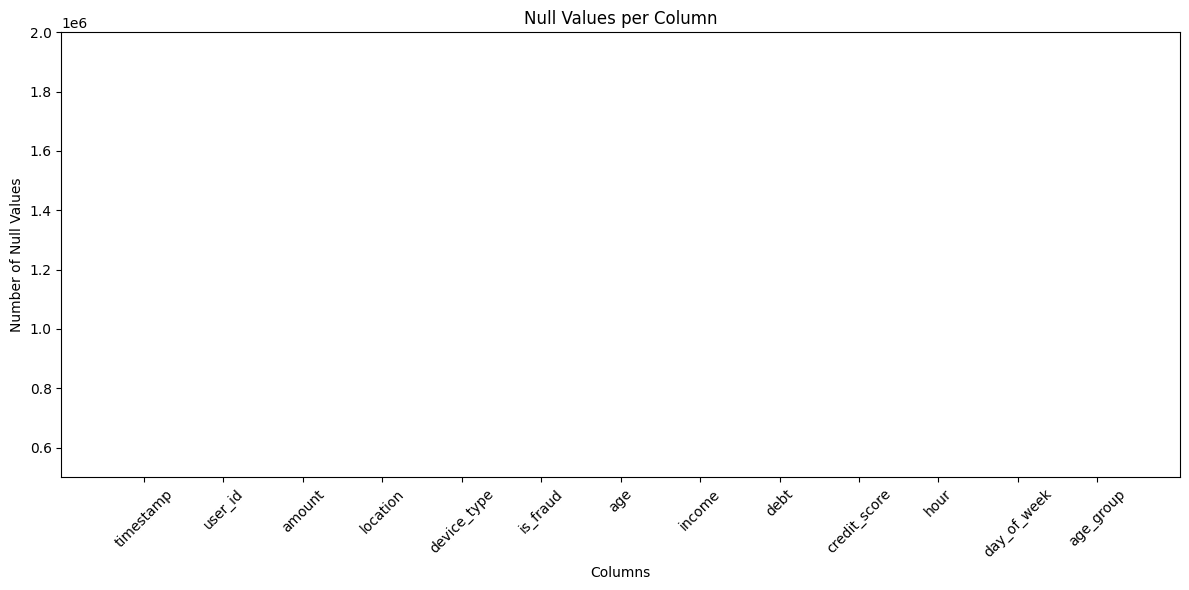

In [12]:
# Create age_group with your bins
bins = [18, 25, 35, 45, 55, 65, 75]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '66-75']

df['age_group'] = pd.cut(
    df['age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Count null values
null_counts = df.isnull().sum()

# Plot
plt.figure(figsize=(12,6))
plt.bar(null_counts.index, null_counts.values)

plt.title("Null Values per Column")
plt.xlabel("Columns")
plt.ylabel("Number of Null Values")
plt.xticks(rotation=45)

# 🔹 Set Y-axis range
plt.ylim(500000, 2000000)

plt.tight_layout()
plt.show()

### 3.1 Preprocessing 

### Show Characteristics for column timestamp 

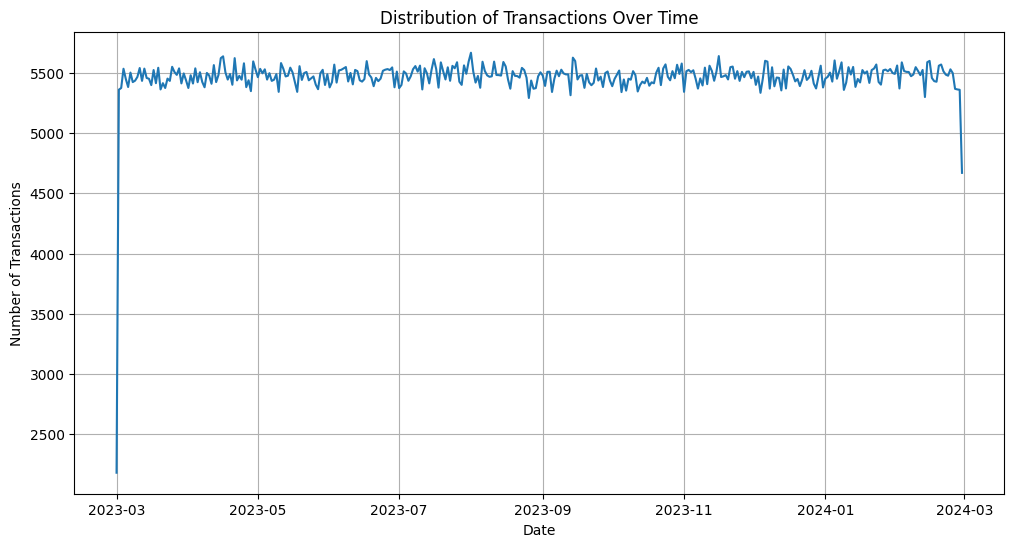

In [13]:

df['timestamp'] = pd.to_datetime(df['timestamp'])


df['date'] = df['timestamp'].dt.date


daily_counts = df.groupby('date').size()


plt.figure(figsize=(12,6))
daily_counts.plot(kind='line')  
plt.title('Distribution of Transactions Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.grid(True)
plt.show()

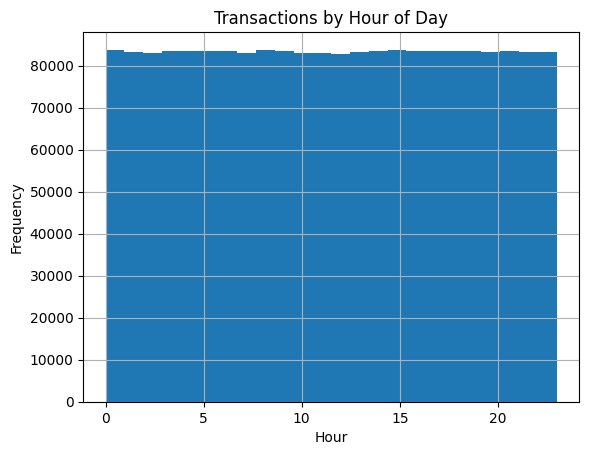

In [14]:
plt.figure()
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["timestamp"].dt.hour.hist(bins=24)
plt.title("Transactions by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Frequency")
plt.show()


### When Fraud Happens By Time

###### | 🌙 **Night**     | 00:00 ≤ hour < 06:00    | 12:00 AM – 5:59 AM  | 🌅 **Morning**   | 06:00 ≤ hour < 12:00    | 6:00 AM – 11:59 AM || 🌇 **Afternoon** | 12:00 ≤ hour < 18:00    | 12:00 PM – 5:59 PM || 🌃 **Evening**   | 18:00 ≤ hour < 24:00    | 6:00 PM – 11:59 PM |


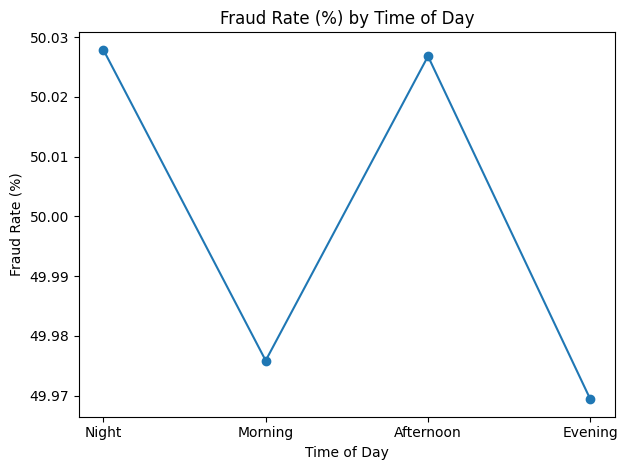

In [15]:
# Extract hour
df['hour'] = pd.to_datetime(df['timestamp']).dt.hour

# Create time-of-day groups for ALL transactions
df['time_period'] = pd.cut(
    df['hour'],
    bins=[0, 6, 12, 18, 24],
    labels=["Night", "Morning", "Afternoon", "Evening"],
    right=False
)

# Calculate fraud rate per time period
fraud_rate_time = (
    df.groupby('time_period')['is_fraud']
    .mean()
    .reset_index()
)

# Convert to percentage
fraud_rate_time['fraud_rate_percent'] = fraud_rate_time['is_fraud'] * 100

# Plot as line
plt.figure()
plt.plot(fraud_rate_time['time_period'], 
         fraud_rate_time['fraud_rate_percent'], 
         marker='o')

plt.title("Fraud Rate (%) by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Fraud Rate (%)")

plt.tight_layout()
plt.show()

### Characteristics For Column Amount 

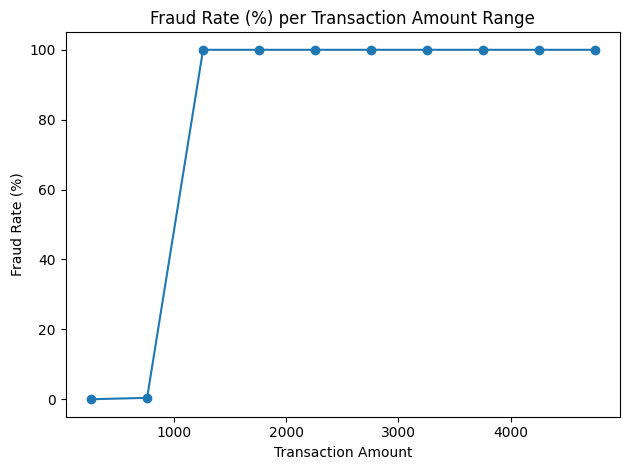

In [16]:
# Create amount bins (10 equal-width ranges)
df['amount_bin'] = pd.cut(df['amount'], bins=10)

# Calculate fraud rate per amount range
fraud_rate_amount = (
    df.groupby('amount_bin')['is_fraud']
    .mean()
    .reset_index()
)

# Convert to percentage
fraud_rate_amount['fraud_rate_percent'] = fraud_rate_amount['is_fraud'] * 100

# Use bin midpoints for plotting
fraud_rate_amount['bin_mid'] = fraud_rate_amount['amount_bin'].apply(lambda x: x.mid)

# Plot
plt.figure()
plt.plot(fraud_rate_amount['bin_mid'], fraud_rate_amount['fraud_rate_percent'], marker='o')

plt.title("Fraud Rate (%) per Transaction Amount Range")
plt.xlabel("Transaction Amount")
plt.ylabel("Fraud Rate (%)")

plt.tight_layout()
plt.show()

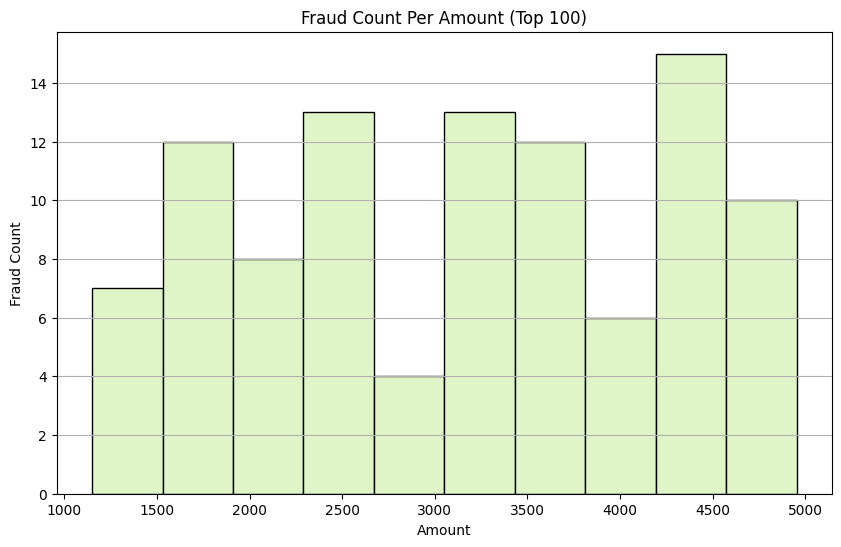

In [17]:
# Filtrer seulement les fraudes
df_fraud = df[df['is_fraud']==1]

# Prendre un échantillon top 100 pour lisibilité
df_sample = df_fraud['amount'].sample(100, random_state=42)

# Histogramme avec couleur nude
plt.figure(figsize=(10,6))
plt.hist(df_sample, bins=10, color="#DFF5C8", edgecolor='black')  # couleur nude
plt.title("Fraud Count Per Amount (Top 100)")
plt.xlabel("Amount")
plt.ylabel("Fraud Count")
plt.grid(axis='y')
plt.show()

### Characteristics For Column Location 

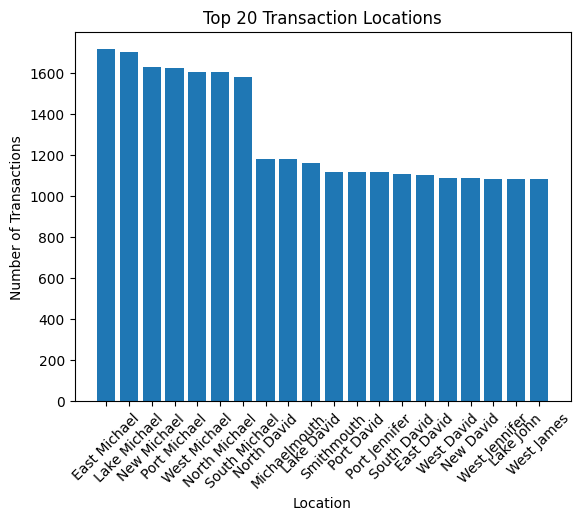

In [18]:
top_locations = df["location"].value_counts().nlargest(20)

plt.figure()
plt.bar(top_locations.index.astype(str), top_locations.values)
plt.title("Top 20 Transaction Locations")
plt.xlabel("Location")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)

plt.show()



### top 10 fraud rate per location

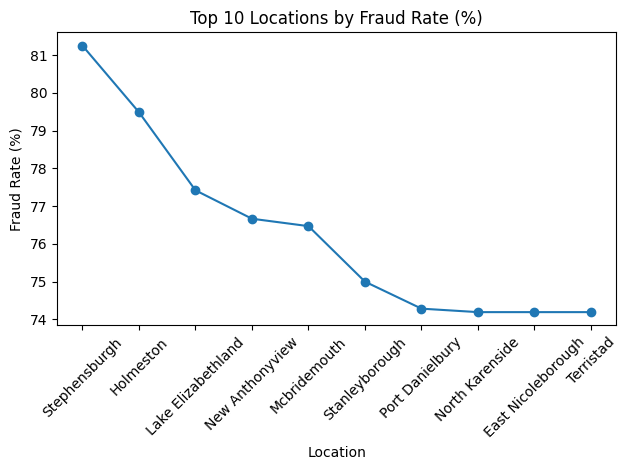

In [19]:


grouped = df.groupby("location")["is_fraud"].agg(["mean", "count"])

# Keep only locations with enough transactions
grouped = grouped[grouped["count"] >= 30]

# Sort by fraud rate
sorted_data = grouped.sort_values("mean", ascending=False)

# Take top 10
top10 = sorted_data.head(10)

# Convert to percentage
fraud_percent = top10["mean"] * 100

plt.figure()
plt.plot(top10.index, fraud_percent, marker='o')

plt.title("Top 10 Locations by Fraud Rate (%)")
plt.xlabel("Location")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



### lowest fraud rates per location 

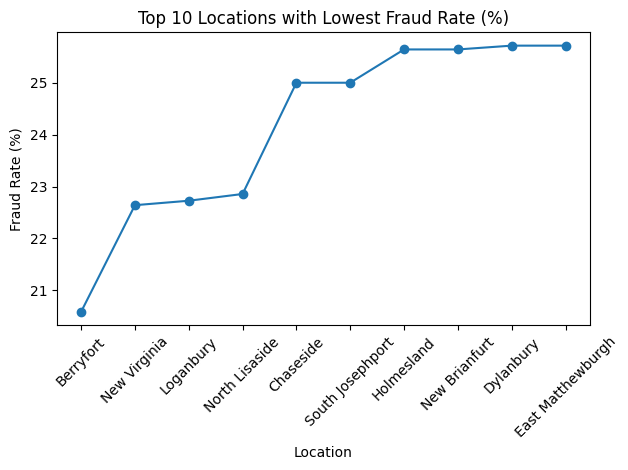

In [20]:


# Group by location
grouped = df.groupby("location")["is_fraud"].agg(["mean", "count"])

# Keep locations with enough transactions (important for reliability)
grouped = grouped[grouped["count"] >= 30]

# Sort by lowest fraud rate
sorted_data = grouped.sort_values("mean", ascending=True)

# Select bottom 10 locations
bottom10 = sorted_data.head(10)

# Convert to percentage
fraud_percent = bottom10["mean"] * 100

# Plot
plt.figure()
plt.plot(bottom10.index, fraud_percent, marker='o')

plt.title("Top 10 Locations with Lowest Fraud Rate (%)")
plt.xlabel("Location")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


### Device Type Characteristics 

### The Most Affected Devices 

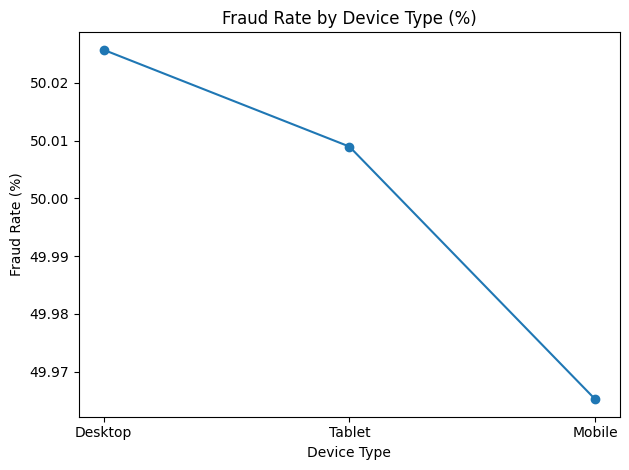

In [21]:


# Calculate fraud rate per device
device_fraud = df.groupby("device_type")["is_fraud"].mean() * 100

# Sort from highest to lowest
device_fraud = device_fraud.sort_values(ascending=False)

# Plot
plt.figure()
plt.plot(device_fraud.index, device_fraud.values, marker='o')

plt.title("Fraud Rate by Device Type (%)")
plt.xlabel("Device Type")
plt.ylabel("Fraud Rate (%)")

plt.tight_layout()
plt.show()


### IsFraud(target variable) Characteristics 

### Age Characteristics 

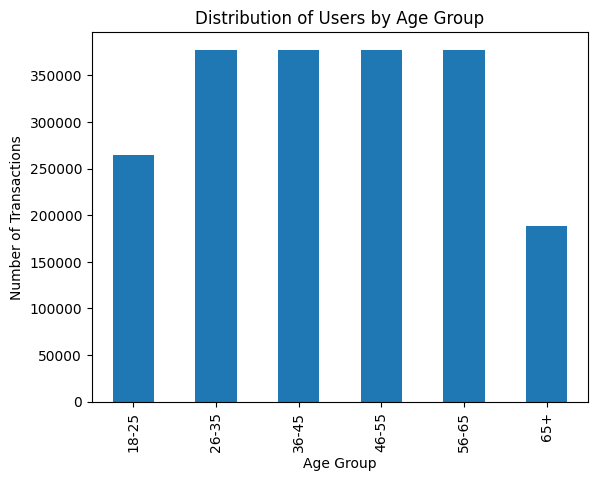

In [22]:


# Create age groups
bins = [18, 25, 35, 45, 55, 65, 100]
labels = ["18-25", "26-35", "36-45", "46-55", "56-65", "65+"]

df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels)

# Plot
plt.figure()

df["age_group"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Users by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Transactions")

plt.show()






### the most age range affected by fraud 

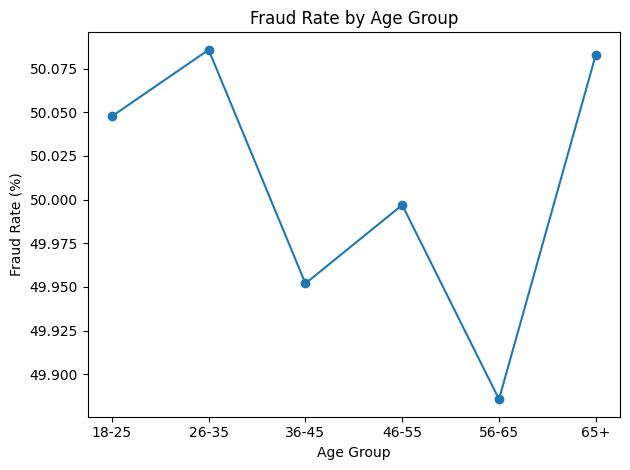

In [23]:



# Clean column names
df.columns = df.columns.str.strip()

# Detect fraud column
fraud_col = None
for col in df.columns:
    if col.lower() in ["is_fraud", "isfraud"]:
        fraud_col = col
        break

# Create ordered age groups
bins = [18, 26, 36, 46, 56, 66, 120]
labels = ["18-25", "26-35", "36-45", "46-55", "56-65", "65+"]
df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels, right=False)

# Calculate fraud rate by age group
age_fraud = df.groupby("age_group")[fraud_col].mean() * 100
age_fraud = age_fraud.reindex(labels)

# Plot
plt.figure()
plt.plot(age_fraud.index, age_fraud.values, marker='o')
plt.xlabel("Age Group")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Age Group")
plt.tight_layout()
plt.show()


### Transaction Timing per Age

In [24]:
df[['age', 'amount']].corr()

,age,amount
age,1.000000,-0.000563
amount,-0.000563,1.000000


### Income Characteristics 

### Fraud Rate Per Income 

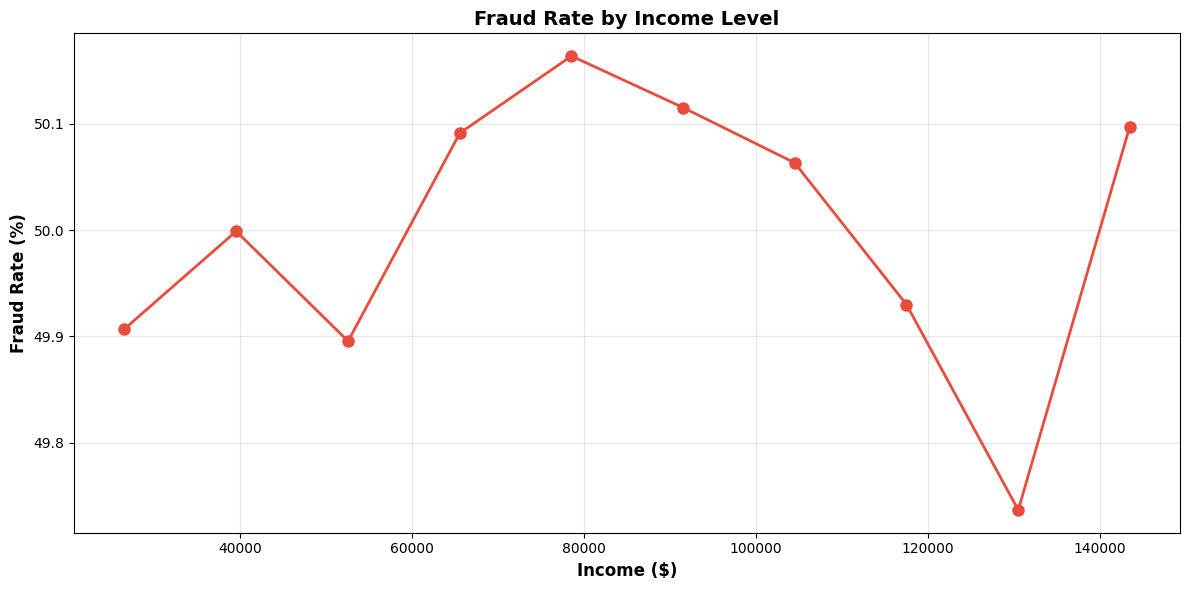

Fraud Rate by Income Bracket:
                          fraud_rate
income                              
(20000.089, 32995.098]       49.9070
(32995.098, 46014.172]       49.9990
(46014.172, 59048.364]       49.8955
(59048.364, 72042.05]        50.0915
(72042.05, 85032.87]         50.1640
(85032.87, 97998.086]        50.1155
(97998.086, 111009.909]      50.0635
(111009.909, 124046.366]     49.9300
(124046.366, 137031.813]     49.7365
(137031.813, 149999.96]      50.0975


In [25]:





# Create income bins
income_bins = pd.qcut(df['income'], q=10, duplicates='drop')

# Calculate fraud rate per income bin
fraud_rate_by_income = df.groupby(income_bins)['is_fraud'].agg(['sum', 'count'])
fraud_rate_by_income['fraud_rate'] = (fraud_rate_by_income['sum'] / fraud_rate_by_income['count']) * 100

# Get the midpoint of each income bin for plotting
income_midpoints = [interval.mid for interval in fraud_rate_by_income.index]

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(income_midpoints, fraud_rate_by_income['fraud_rate'].values, marker='o', linewidth=2, markersize=8, color='#e74c3c')
plt.xlabel('Income ($)', fontsize=12, fontweight='bold')
plt.ylabel('Fraud Rate (%)', fontsize=12, fontweight='bold')
plt.title('Fraud Rate by Income Level', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fraud_rate_by_income.png', dpi=300, bbox_inches='tight')
plt.show()

print('Fraud Rate by Income Bracket:')
print(fraud_rate_by_income[['fraud_rate']])

### Debt Characterisitcs 

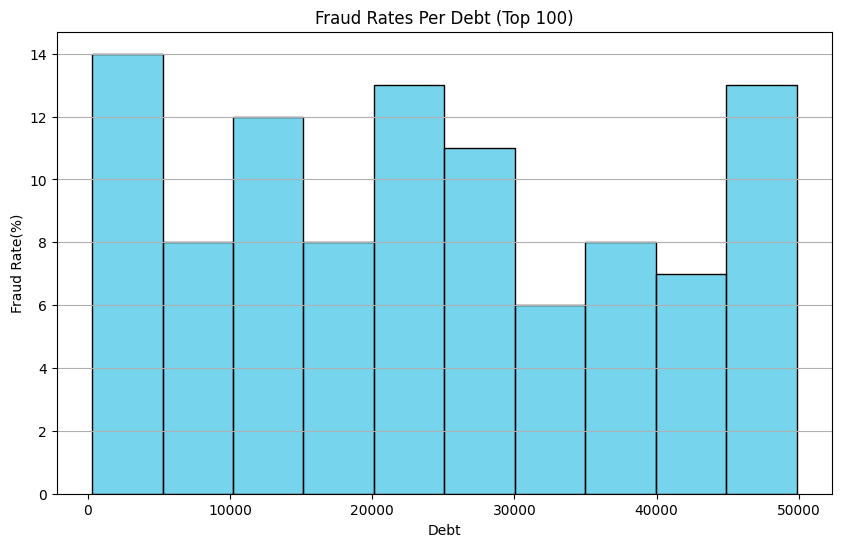

In [26]:
# Filtrer seulement les fraudes
df_fraud = df[df['is_fraud']==1]

# Prendre un échantillon top 100 pour lisibilité
df_sample = df_fraud['debt'].sample(100, random_state=42)

# Calculer histogramme et convertir en pourcentage
counts, bins = np.histogram(df_sample, bins=10)
percentages = (counts / counts.sum()) * 100  # pourcentage

# Graphe
plt.figure(figsize=(10,6))
plt.bar(bins[:-1], percentages, width=np.diff(bins), color="#1BB9E099", edgecolor='black', align='edge')
plt.title("Fraud Rates Per Debt (Top 100)")
plt.xlabel("Debt")
plt.ylabel("Fraud Rate(%)")
plt.grid(axis='y')
plt.show()

### Credit Score Characteristics 

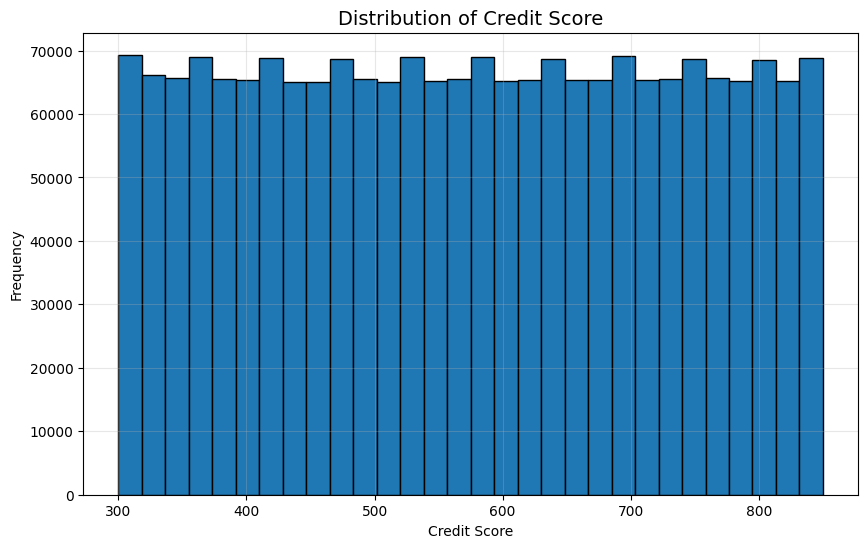

In [27]:
plt.figure(figsize=(10, 6))
plt.hist(df["credit_score"], bins=30, edgecolor='black')
plt.title("Distribution of Credit Score", fontsize=14)
plt.xlabel("Credit Score")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()


### Fraud Rate by credit_score 

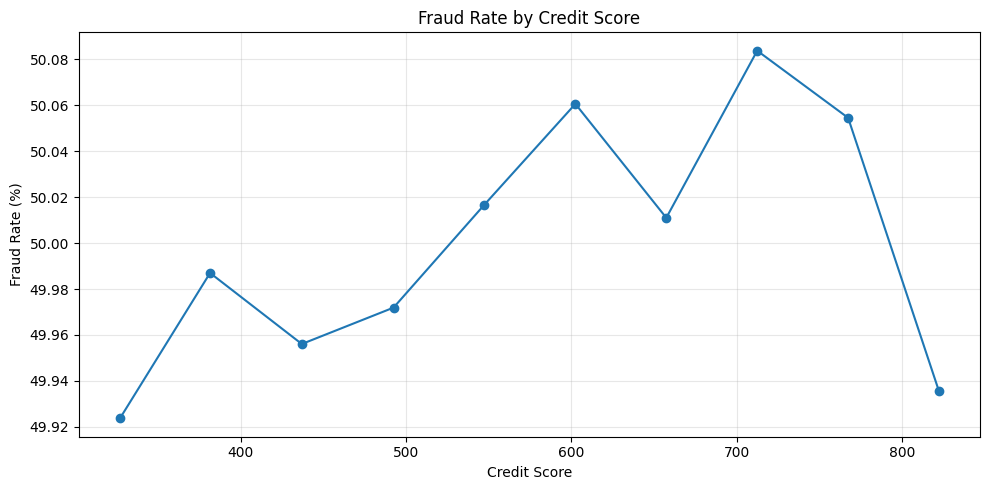

Saved fraud_by_credit_score.png
                  fraud_rate
credit_score                
(299.999, 354.0]   49.923664
(354.0, 409.0]     49.986995
(409.0, 465.0]     49.956050
(465.0, 520.0]     49.971904
(520.0, 575.0]     50.016776
(575.0, 630.0]     50.060652
(630.0, 685.0]     50.011024
(685.0, 740.0]     50.083820
(740.0, 795.0]     50.054577
(795.0, 850.0]     49.935386


In [28]:
try:
    df
except NameError:
    df = pd.read_csv('fraud_detection_dataset.csv')

credit_bins = pd.qcut(df['credit_score'], q=10, duplicates='drop')
credit_agg = df.groupby(credit_bins)['is_fraud'].agg(['sum','count'])
credit_agg['fraud_rate'] = credit_agg['sum']/credit_agg['count']*100
credit_mid = [interval.mid for interval in credit_agg.index]
plt.figure(figsize=(10,5))
plt.plot(credit_mid, credit_agg['fraud_rate'].values, marker='o', color='tab:blue')
plt.xlabel('Credit Score')
plt.ylabel('Fraud Rate (%)')
plt.title('Fraud Rate by Credit Score')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fraud_by_credit_score.png', dpi=300, bbox_inches='tight')
plt.show()

print('Saved fraud_by_credit_score.png')
print(credit_agg[['fraud_rate']])